In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [133]:
dir1 = "MixedPlay/50reps_100eps_100epL_02jan2026_IQL_vs_IQL"
dir2 = "MixedPlay/50reps_100eps_100epL_03jan2026_IQL_vs_IQL"
df_1 = pd.read_csv(f"{dir1}/eval_returns.csv", index_col=0)
df_2 = pd.read_csv(f"{dir2}/eval_returns.csv", index_col=0)

df_1.head()

,agent_1_returns,agent_2_returns
repetition,,
1,"[0.08, 0.08, 0.0, 0.4, 0.08, 0.4, 0.08, 0.08, ...","[0.12, 0.12, 0.2, 0.6, 0.12, 0.6, 0.12, 0.12, ..."
2,"[0.4, 0.4, 0.08, 0.32, 0.08, 0.52, 0.4, 0.4, 0...","[0.6, 0.6, 0.12, 0.6799999999999999, 0.12, 0.4..."
3,"[0.52, 0.52, 0.52, 0.32, 0.52, 0.52, 0.52, 0.5...","[0.48, 0.48, 0.48, 0.6799999999999999, 0.48, 0..."
4,"[0.52, 0.52, 0.52, 0.52, 0.52, 0.52, 0.52, 0.5...","[0.48, 0.48, 0.48, 0.48, 0.48, 0.48, 0.48, 0.4..."
5,"[0.2, 0.2, 0.2, 0.0, 0.2, 0.2, 0.2, 0.2, 0.2, ...","[0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
def _to_list(l):
    l = l[1:-1].split(", ")
    return [float(elm) for elm in l]

df_1["agent_1_returns"] = df_1["agent_1_returns"].apply(_to_list)
df_1["agent_2_returns"] = df_1["agent_2_returns"].apply(_to_list)
df_2["agent_1_returns"] = df_2["agent_1_returns"].apply(_to_list)
df_2["agent_2_returns"] = df_2["agent_2_returns"].apply(_to_list)

df_1["agent_1_mean"] = df_1["agent_1_returns"].apply(np.mean)
df_1["agent_2_mean"] = df_1["agent_2_returns"].apply(np.mean)
df_1["agent_1_std"] = df_1["agent_1_returns"].apply(np.std)
df_1["agent_2_std"] = df_1["agent_2_returns"].apply(np.std)

df_2["agent_1_mean"] = df_2["agent_1_returns"].apply(np.mean)
df_2["agent_2_mean"] = df_2["agent_2_returns"].apply(np.mean)
df_2["agent_1_std"] = df_2["agent_1_returns"].apply(np.std)
df_2["agent_2_std"] = df_2["agent_2_returns"].apply(np.std)

In [ ]:
def bootstrap_distribution(data, B=10000, confidence_level=0.95, b = 10):

    if isinstance(data[0], list):
        n = len(data[0])
        data = np.array([np.mean(np.random.choice(d, size=n, replace=True)) for d in data for _ in range(b)])
        N = len(data)
        observed_mean = np.mean(np.mean(data))
    else:
        data = np.array(data)
        N = len(data)
        observed_mean = np.mean(data)

    bootstrap_means = np.array([
        np.mean(np.random.choice(data, size=N, replace=True))
        for _ in range(B)
    ])
    
    #CI
    alpha = 1 - confidence_level
    ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    
    # Bootstrap standard error
    se = np.std(bootstrap_means)
    
    return bootstrap_means, ci_lower, ci_upper, observed_mean, se

# Run bootstrap on agent_1_mean
def hist_result(agent_statistics):
    bootstrap_means, ci_lower, ci_upper, observed_mean, se = bootstrap_distribution(agent_statistics)

    # Summary statistics
    print(f"Observed mean: {observed_mean:.4f}")
    print(f"Bootstrap SE: {se:.4f}")
    print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

    # Plot bootstrap distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograms
    axes[0].hist(bootstrap_means, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    axes[0].axvline(observed_mean, color='red', linestyle='--', linewidth=2, label=f'Observed mean: {observed_mean:.3f}')
    axes[0].axvline(ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
    axes[0].axvline(ci_upper, color='orange', linestyle=':', linewidth=2)
    axes[0].set_xlabel('Bootstrap Mean')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Bootstrap Distribution of Agent 1 Mean Return')
    axes[0].legend()

    #comparison
    axes[1].hist(agent_statistics, bins=20, density=True, alpha=0.7, color='forestgreen', edgecolor='white')
    axes[1].axvline(observed_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {observed_mean:.3f}')
    axes[1].set_xlabel('Mean Return per Repetition')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Original Distribution of Agent 1 Mean Returns')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Observed mean: 0.3392
Bootstrap SE: 0.0163
95% CI: [0.3073, 0.3710]


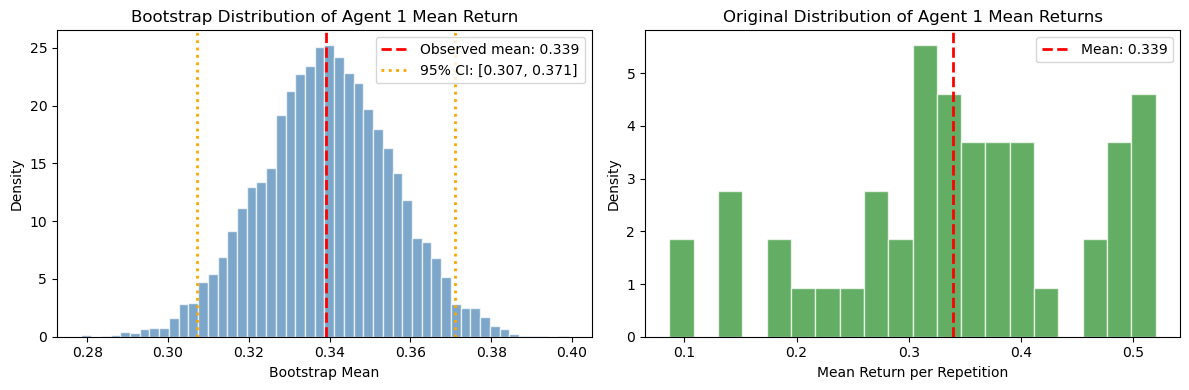

In [163]:
hist_result(df_1["agent_1_mean"].values)

Observed mean: 0.4910
Bootstrap SE: 0.0206
95% CI: [0.4496, 0.5303]


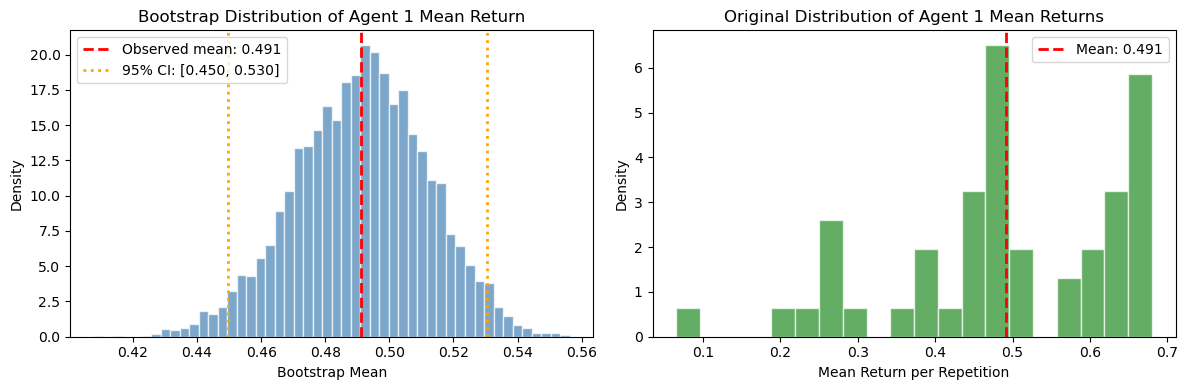

In [ ]:
hist_result(df_2["agent_1_mean"].values)

(array([[ 2., 21.,  0.,  1.,  0.,  0.,  2.,  4.,  0.,  0.],
        [ 1.,  9.,  0.,  2.,  0.,  0.,  1., 15.,  0.,  2.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.,  0., 26.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0., 29.],
        [ 3.,  0.,  0., 23.,  0.,  0.,  0.,  0.,  0.,  4.],
        [ 1.,  0.,  0.,  0.,  0.,  0., 29.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  0., 27.],
        [ 4.,  0.,  0.,  1.,  0.,  0., 25.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  4.,  0.,  0., 26.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  5., 22.,  0.,  3.],
        [ 1.,  1.,  0.,  0.,  0.,  0., 22.,  0.,  0.,  6.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  2., 23.,  0.,  5.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 25.,  2.,  0.,  3.],
        [ 1.,  0.,  0.,  3.,  0.,  0.,  1.,  0.,  0., 25.],
        [ 1.,  0.,  0.,  0.,  0.,  0.,  2., 22.,  0.,  5.],
        [ 1.,  0.,  0.,  0.,  0.,  0.,  1., 24.,  0.,  4.],
        [ 2.,  0.,  0., 20.,  0.,  0.,  

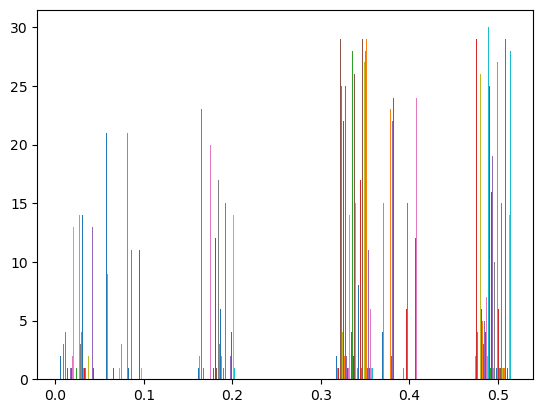

In [169]:
#a1_returns = [_to_list(l) for l in df_1["agent_1_returns"].values]
all_a1_returns = np.asarray(df_1["agent_1_returns"].values).flatten()
plt.hist(all_a1_returns, bins=10)

In [171]:
# Welch's t-test: two-sided difference test comparing agent_1_mean vs agent_2_mean

# Extract the mean returns for each agent
agent_1_means = df_1["agent_1_mean"].values
agent_2_means = df_2["agent_1_mean"].values

# Perform Welch's t-test (does not assume equal variances)
t_statistic, p_value = stats.ttest_ind(agent_1_means, agent_2_means, equal_var=False)

print("Welch's t-test: Agent 1 Mean vs Agent 2 Mean")
print("=" * 50)
print(f"Agent 1 mean: {np.mean(agent_1_means):.4f} ± {np.std(agent_1_means):.4f}")
print(f"Agent 2 mean: {np.mean(agent_2_means):.4f} ± {np.std(agent_2_means):.4f}")
print(f"Difference: {np.mean(agent_1_means) - np.mean(agent_2_means):.4f}")
print("-" * 50)
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value (two-sided): {p_value:.6f}")
print("-" * 50)

# Interpretation
alpha = 0.05
if p_value < alpha:
    print(f"Result: SIGNIFICANT difference at α = {alpha}")
    print("Reject the null hypothesis: the means are significantly different.")
else:
    print(f"Result: NO significant difference at α = {alpha}")
    print("Fail to reject the null hypothesis: no significant difference between means.")

Welch's t-test: Agent 1 Mean vs Agent 2 Mean
Agent 1 mean: 0.3392 ± 0.1146
Agent 2 mean: 0.3483 ± 0.1344
Difference: -0.0091
--------------------------------------------------
t-statistic: -0.3615
p-value (two-sided): 0.718527
--------------------------------------------------
Result: NO significant difference at α = 0.05
Fail to reject the null hypothesis: no significant difference between means.


In [118]:
# =============================================================================
# Levene's Test: Compare Variance (Stability) Between Experiments
# =============================================================================
# Tests if two groups have equal variances. Lower variance = more stable convergence.

print("=" * 60)
print("LEVENE'S TEST FOR EQUAL VARIANCES (Convergence Stability)")
print("=" * 60)

# Test on Agent 1 means across repetitions
stat_a1, p_value_a1 = stats.levene(df_1["agent_1_mean"], df_2["agent_1_mean"])

print("\nAgent 1 - Cross-repetition variance comparison:")
print(f"  Exp 1 variance: {np.var(df_1['agent_1_mean']):.6f}")
print(f"  Exp 2 variance: {np.var(df_2['agent_1_mean']):.6f}")
print(f"  Levene statistic: {stat_a1:.4f}")
print(f"  p-value: {p_value_a1:.6f}")

if p_value_a1 < 0.05:
    more_stable = "Exp 1" if np.var(df_1['agent_1_mean']) < np.var(df_2['agent_1_mean']) else "Exp 2"
    print(f"  → SIGNIFICANT: Variances differ! {more_stable} is more stable.")
else:
    print("  → No significant difference in variance (similar stability)")

# Test on Agent 2 means across repetitions
stat_a2, p_value_a2 = stats.levene(df_1["agent_2_mean"], df_2["agent_2_mean"])

print("\nAgent 2 - Cross-repetition variance comparison:")
print(f"  Exp 1 variance: {np.var(df_1['agent_2_mean']):.6f}")
print(f"  Exp 2 variance: {np.var(df_2['agent_2_mean']):.6f}")
print(f"  Levene statistic: {stat_a2:.4f}")
print(f"  p-value: {p_value_a2:.6f}")

if p_value_a2 < 0.05:
    more_stable = "Exp 1" if np.var(df_1['agent_2_mean']) < np.var(df_2['agent_2_mean']) else "Exp 2"
    print(f"  → SIGNIFICANT: Variances differ! {more_stable} is more stable.")
else:
    print("  → No significant difference in variance (similar stability)")


LEVENE'S TEST FOR EQUAL VARIANCES (Convergence Stability)

Agent 1 - Cross-repetition variance comparison:
  Exp 1 variance: 0.013123
  Exp 2 variance: 0.018065
  Levene statistic: 1.3531
  p-value: 0.247558
  → No significant difference in variance (similar stability)

Agent 2 - Cross-repetition variance comparison:
  Exp 1 variance: 0.027858
  Exp 2 variance: 0.020871
  Levene statistic: 1.4072
  p-value: 0.238382
  → No significant difference in variance (similar stability)


WITHIN-RUN VARIANCE COMPARISON (Trajectory Stability)

Agent 1 - Within-run variance comparison:
  Exp 1 median within-run variance: 0.008804
  Exp 2 median within-run variance: 0.009149
  Exp 1 mean within-run variance:   0.012668
  Exp 2 mean within-run variance:   0.011871
  Mann-Whitney U: 1366.0000
  p-value: 0.425798
  → No significant difference in within-run stability

Agent 2 - Within-run variance comparison:
  Exp 1 median within-run variance: 0.015732
  Exp 2 median within-run variance: 0.009351
  Exp 1 mean within-run variance:   0.025303
  Exp 2 mean within-run variance:   0.019263
  Mann-Whitney U: 1454.5000
  p-value: 0.159573
  → No significant difference in within-run stability


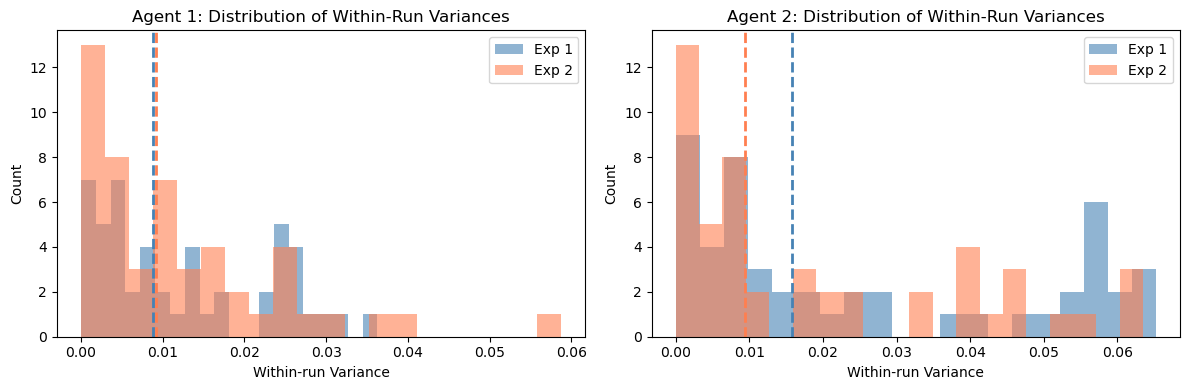

In [119]:
# =============================================================================
# Within-Run Variance Comparison (Trajectory Stability)
# =============================================================================
# Compares variance WITHIN each run - are individual trajectories more stable?

def within_run_variance(returns_column):
    """Compute variance within each repetition's evaluation returns."""
    variances = []
    for returns_str in returns_column:
        returns = _to_list(returns_str)
        variances.append(np.var(returns))
    return np.array(variances)

print("=" * 60)
print("WITHIN-RUN VARIANCE COMPARISON (Trajectory Stability)")
print("=" * 60)

# Agent 1 within-run variances
within_var_1_a1 = within_run_variance(df_1["agent_1_returns"])
within_var_2_a1 = within_run_variance(df_2["agent_1_returns"])

stat_a1, p_value_a1 = stats.mannwhitneyu(within_var_1_a1, within_var_2_a1, alternative='two-sided')

print("\nAgent 1 - Within-run variance comparison:")
print(f"  Exp 1 median within-run variance: {np.median(within_var_1_a1):.6f}")
print(f"  Exp 2 median within-run variance: {np.median(within_var_2_a1):.6f}")
print(f"  Exp 1 mean within-run variance:   {np.mean(within_var_1_a1):.6f}")
print(f"  Exp 2 mean within-run variance:   {np.mean(within_var_2_a1):.6f}")
print(f"  Mann-Whitney U: {stat_a1:.4f}")
print(f"  p-value: {p_value_a1:.6f}")

if p_value_a1 < 0.05:
    more_stable = "Exp 1" if np.median(within_var_1_a1) < np.median(within_var_2_a1) else "Exp 2"
    print(f"  → SIGNIFICANT: {more_stable} has more stable trajectories within runs.")
else:
    print("  → No significant difference in within-run stability")

# Agent 2 within-run variances
within_var_1_a2 = within_run_variance(df_1["agent_2_returns"])
within_var_2_a2 = within_run_variance(df_2["agent_2_returns"])

stat_a2, p_value_a2 = stats.mannwhitneyu(within_var_1_a2, within_var_2_a2, alternative='two-sided')

print("\nAgent 2 - Within-run variance comparison:")
print(f"  Exp 1 median within-run variance: {np.median(within_var_1_a2):.6f}")
print(f"  Exp 2 median within-run variance: {np.median(within_var_2_a2):.6f}")
print(f"  Exp 1 mean within-run variance:   {np.mean(within_var_1_a2):.6f}")
print(f"  Exp 2 mean within-run variance:   {np.mean(within_var_2_a2):.6f}")
print(f"  Mann-Whitney U: {stat_a2:.4f}")
print(f"  p-value: {p_value_a2:.6f}")

if p_value_a2 < 0.05:
    more_stable = "Exp 1" if np.median(within_var_1_a2) < np.median(within_var_2_a2) else "Exp 2"
    print(f"  → SIGNIFICANT: {more_stable} has more stable trajectories within runs.")
else:
    print("  → No significant difference in within-run stability")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(within_var_1_a1, bins=20, alpha=0.6, label='Exp 1', color='steelblue')
axes[0].hist(within_var_2_a1, bins=20, alpha=0.6, label='Exp 2', color='coral')
axes[0].axvline(np.median(within_var_1_a1), color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(np.median(within_var_2_a1), color='coral', linestyle='--', linewidth=2)
axes[0].set_xlabel('Within-run Variance')
axes[0].set_ylabel('Count')
axes[0].set_title('Agent 1: Distribution of Within-Run Variances')
axes[0].legend()

axes[1].hist(within_var_1_a2, bins=20, alpha=0.6, label='Exp 1', color='steelblue')
axes[1].hist(within_var_2_a2, bins=20, alpha=0.6, label='Exp 2', color='coral')
axes[1].axvline(np.median(within_var_1_a2), color='steelblue', linestyle='--', linewidth=2)
axes[1].axvline(np.median(within_var_2_a2), color='coral', linestyle='--', linewidth=2)
axes[1].set_xlabel('Within-run Variance')
axes[1].set_ylabel('Count')
axes[1].set_title('Agent 2: Distribution of Within-Run Variances')
axes[1].legend()

plt.tight_layout()
plt.show()
